# **Implementing Polynomial Regression using Scikit-Learn Library**

In [3]:
# Importing Models:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# Loading Dataset:
df = pd.read_csv('Salary_Data.csv')

In [ ]:
# Extracting Features:
X = df[['YearsExperience']].values  # Independent variable
Y = df['Salary'].values  # Dependent variable

In [16]:
X=X.reshape(-1,1)


In [15]:
Y=Y.reshape(-1,1)


In [17]:
sc=StandardScaler()
X=sc.fit_transform(X)
Y=sc.fit_transform(Y)

In [18]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [23]:
# Transform data to polynomial features (degree = 3 for example)
poly = PolynomialFeatures(degree=3)  # You can adjust the degree
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [24]:
# Create and train the Polynomial Regression model
model = LinearRegression()
model.fit(X_poly_train, Y_train)

LinearRegression()

In [25]:
# Predict salaries for the test set
Y_pred = model.predict(X_poly_test)

(1, 4)


array([74594.83859153])

Regression Equation: Y = 74594.84 + 31001.19X^1 + 1618.79X^2 - 2571.00X^3
Mean Squared Error (MSE): 48605815.33
R² Score: 0.9048


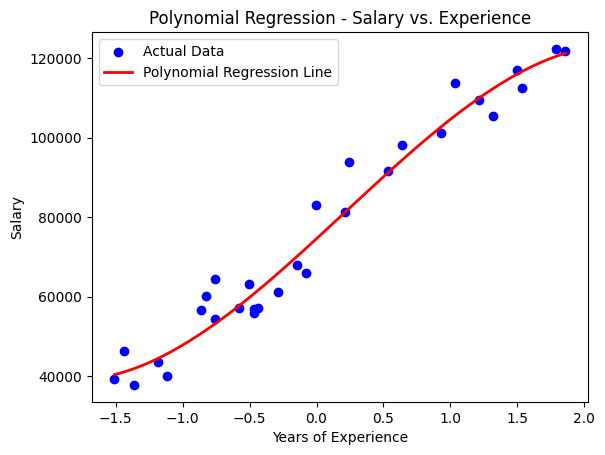

In [36]:
# Calculate Mean Squared Error (MSE) and R² Score
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

# Print model parameters and evaluation metrics
equation = f"Regression Equation: Y = {model.intercept_[0]:.2f}"
for i, coef in enumerate(model.coef_[0]):
    if i > 0: # The first coefficient is the intercept
        if coef >= 0:
            equation += f" + {coef:.2f}X^{i}"
        else:
            equation += f" - {abs(coef):.2f}X^{i}"
print(equation)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# Visualizing the polynomial regression curve
X_grid = np.linspace(min(X), max(X), 100).reshape(-1, 1) # give array of equally space data containing 100 points
X_grid_poly = poly.transform(X_grid)
Y_grid_pred = model.predict(X_grid_poly)

plt.scatter(X, Y, color='blue', label='Actual Data')  # Scatter plot of actual data
plt.plot(X_grid, Y_grid_pred, color='red', linewidth=2, label='Polynomial Regression Line')  # Polynomial curve
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Polynomial Regression - Salary vs. Experience")
plt.legend()
plt.show()

### **Summary**  

This Python script implements **Polynomial Regression** to model the relationship between **Years of Experience** and **Salary** using **scikit-learn**.  

1. **Data Loading & Preprocessing:**  
   - Reads the dataset (`a.csv`) using **pandas**.  
   - Extracts **YearsExperience** (`X`) as the independent variable and **Salary** (`Y`) as the dependent variable.  
   - Splits the dataset into **80% training** and **20% testing** sets.  

2. **Polynomial Feature Transformation:**  
   - Transforms `X` into polynomial features of **degree 3** (modifiable) using **PolynomialFeatures**.  
   - Generates **higher-order terms** to capture nonlinear relationships.  

3. **Model Training & Prediction:**  
   - Trains a **Linear Regression model** on the transformed polynomial features.  
   - Predicts salaries for the test set.  

4. **Model Evaluation:**  
   - Computes **Mean Squared Error (MSE)** and **R² Score** to assess prediction accuracy.  
   - Prints the **polynomial regression equation** and model performance metrics.  

5. **Visualization:**  
   - **Scatter plot** of actual data points.  
   - **Smooth polynomial regression curve** over 100 evenly spaced data points.  

This approach improves prediction accuracy when the relationship between **experience and salary** is nonlinear. 🚀